# PINN example notebook: Logistic Regression

This is an example notebook to learn the basics of Pysics Informed Neural Networks (PINNs) with a very simple example:|
Logistic Regression

The differential equation for logistic regression can be solved analytically. \
Using a neural network to learn this solution to the problem aims to explain the concept and application of a PINN to differential equations in general.

In [190]:
import torch 
import torchopt
from torch import nn

import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np

from functorch import make_functional
from torch.func import grad, vmap

import torch.nn as nn

In [288]:
# NNApproximator will be the neural network consisting of an input layer, 
# an output layer, hidden layers in betwee n and tanh as activation function
class NNApproximator(nn.Module):
    def __init__(
        self,
        num_inputs: int = 1,
        num_outputs: int = 1,
        num_hidden: int = 2,
        dim_hidden: int = 2,
        act: nn.Module = nn.Tanh(),
    ) -> None:
        """Simple neural network with linear layers and non-linear activation function
        This class is used as universal function approximator for the solution of
        partial differential equations using PINNs
        Args:
            num_inputs (int, optional): The number of input dimensions
            num_outputs (int, optional): The number of outputs of the model, in general is 1
            num_hidden (int, optional): The number of hidden layeim_hidden rs in the model
            dim_hidden (int, optional): The number of neurons for each hidden layer
            act (nn.Module, optional): The type of non-linear activation function to be used
        """
        super().__init__()

        # creates linear input and output layers 
        
        # input layer has num_input inputs neurons and dim_hidden outputs
        self.layer_in = nn.Linear(num_inputs, dim_hidden)
        # output layer has dim_hidden inputs neurons and num_outputs outputs
        self.layer_out = nn.Linear(dim_hidden, num_outputs)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

        self.num_inputs = num_inputs
        self.num_outputs = num_outputs

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.layer_in(x))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        return self.layer_out(out)


In [289]:
# create the PINN model
model = NNApproximator()
# create a dictionary using the parameter names connected with its values
params = dict(model.named_parameters())

In [290]:
# Define a function that applies the model to an input vector 
# using the squeeze method to get x into the right form
def apply_model(x):
    return model(x.unsqueeze(0)).squeeze(0)

# Apply the model to the input using vmap
model_v = torch.vmap(apply_model)

# computing its derivative using grad 
# important: first apply grad and then use the vmap. You can only grad scalar functions.
diff_model= torch.func.grad(apply_model)
diff_model_v= torch.vmap(diff_model)

In [294]:
R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value

# defining a loss function consisting of two parts
# first part calculates the loss in resect to the differential equation
# second parts sets bounday conditions so that the solution converges
def loss_fn(params: torch.Tensor, x: torch.Tensor, model_v) -> torch.Tensor:

    # interior loss
    f_value = model_v(x)
    
    interior = diff_model_v(x)- R * f_value * (1 - f_value)

    # boundary loss
    x0 = X_BOUNDARY
    f0 = F_BOUNDARY
    x_boundary = torch.tensor([x0])
    f_boundary = torch.tensor([f0])
    # calculates difference between the the functional value at the boundary and the aimed value
    boundary = model_v(x_boundary)- f_boundary

    # calculates the mean squared error using the nn.MSELoss function
    loss = nn.MSELoss()
    # adding both losses to a total loss
    # the loss function takes its two inputs and calculates the mse of those
    # therefore the second entry is a tensor with the same dimensions but with zeroes 
    loss_value = loss(interior, torch.zeros_like(interior)) + loss(
        boundary, torch.zeros_like(boundary)
    )

    return loss_value

In [295]:
# choose the configuration
batch_size = 30  # number of colocation points sampled in the domain
num_iter =1000 # maximum number of iterations
learning_rate = 1e-3  # learning rate
domain = (-5.0, 5.0)  # logistic equation domain

# choose optimizer with functional API using functorch


#list that keeps track of the loss evolution
loss_evolution = []

# train the model
for i in range(num_iter):

    # sample colocations points in the domain randomly at each epoch
    x = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])
    output = model_v(x)
    
    #initializing  the optimizer with model parameters
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # update the parameters using the functional API
    loss = loss_fn(params, x, model_v)
    optimizer.zero_grad()  # Clear the gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update the model parameters
    

    print(f"Iteration {i} with loss {float(loss)}")
    
    #appends the loss from every iteration to the loss_evolution list
    loss_evolution.append(float(loss))

# plot solution on the given domain



Iteration 0 with loss 1.5579400496790186e-05
Iteration 1 with loss 1.3331205991562456e-05
Iteration 2 with loss 1.7666992789600044e-05
Iteration 3 with loss 1.5813995560165495e-05
Iteration 4 with loss 1.349570902675623e-05
Iteration 5 with loss 1.761785097187385e-05
Iteration 6 with loss 1.482766674598679e-05
Iteration 7 with loss 1.9508242985466495e-05
Iteration 8 with loss 1.3820674212183803e-05
Iteration 9 with loss 1.6713827790226787e-05
Iteration 10 with loss 1.8080649169860408e-05
Iteration 11 with loss 1.3599998055724427e-05
Iteration 12 with loss 1.5813118807272986e-05
Iteration 13 with loss 1.1128147889394313e-05
Iteration 14 with loss 1.2174510629847646e-05
Iteration 15 with loss 1.6344072719221003e-05
Iteration 16 with loss 1.594662717252504e-05
Iteration 17 with loss 1.5062249985930976e-05
Iteration 18 with loss 1.5457051631528884e-05
Iteration 19 with loss 1.7493253835709766e-05
Iteration 20 with loss 1.3863764252164401e-05
Iteration 21 with loss 1.671678910497576e-05
Ite

Iteration 234 with loss 1.487877580075292e-05
Iteration 235 with loss 1.4565250239684246e-05
Iteration 236 with loss 1.536370655230712e-05
Iteration 237 with loss 1.7838843632489443e-05
Iteration 238 with loss 1.2397606042213738e-05
Iteration 239 with loss 1.1093459761468694e-05
Iteration 240 with loss 1.573794725118205e-05
Iteration 241 with loss 1.1236576028750278e-05
Iteration 242 with loss 1.4978717445046641e-05
Iteration 243 with loss 1.3218846106610727e-05
Iteration 244 with loss 1.545633131172508e-05
Iteration 245 with loss 9.987788871512748e-06
Iteration 246 with loss 1.3518602827389259e-05
Iteration 247 with loss 1.2022665032418445e-05
Iteration 248 with loss 2.343402047699783e-05
Iteration 249 with loss 1.1992834515694994e-05
Iteration 250 with loss 1.3849480637873057e-05
Iteration 251 with loss 1.2542335753096268e-05
Iteration 252 with loss 1.688644442765508e-05
Iteration 253 with loss 1.0656679478415754e-05
Iteration 254 with loss 1.4527617167914286e-05
Iteration 255 with l

Iteration 426 with loss 1.4683082554256544e-05
Iteration 427 with loss 1.2472959497245029e-05
Iteration 428 with loss 1.3816724276694003e-05
Iteration 429 with loss 1.3164724805392325e-05
Iteration 430 with loss 1.4092902347329073e-05
Iteration 431 with loss 1.4291092156781815e-05
Iteration 432 with loss 1.275838803849183e-05
Iteration 433 with loss 1.519293618912343e-05
Iteration 434 with loss 1.602723204996437e-05
Iteration 435 with loss 1.2599313777172938e-05
Iteration 436 with loss 1.478453486924991e-05
Iteration 437 with loss 1.2302953109610826e-05
Iteration 438 with loss 1.5027735571493395e-05
Iteration 439 with loss 9.841414794209413e-06
Iteration 440 with loss 1.4538332834490575e-05
Iteration 441 with loss 9.12445830181241e-06
Iteration 442 with loss 1.4594646927434951e-05
Iteration 443 with loss 1.113379403250292e-05
Iteration 444 with loss 1.5145834368013311e-05
Iteration 445 with loss 9.500398846284952e-06
Iteration 446 with loss 1.3655435395776294e-05
Iteration 447 with los

Iteration 620 with loss 1.6721525753382593e-05
Iteration 621 with loss 1.175378929474391e-05
Iteration 622 with loss 1.7836799088399857e-05
Iteration 623 with loss 1.201708619191777e-05
Iteration 624 with loss 1.4568024198524654e-05
Iteration 625 with loss 9.457796295464505e-06
Iteration 626 with loss 1.743721622915473e-05
Iteration 627 with loss 1.4566061508958228e-05
Iteration 628 with loss 1.8421847926219925e-05
Iteration 629 with loss 9.400298949913122e-06
Iteration 630 with loss 1.566439459566027e-05
Iteration 631 with loss 9.749742275744211e-06
Iteration 632 with loss 1.631242412258871e-05
Iteration 633 with loss 1.2943037290824577e-05
Iteration 634 with loss 1.5055339645186905e-05
Iteration 635 with loss 1.277913816011278e-05
Iteration 636 with loss 1.772197356331162e-05
Iteration 637 with loss 1.4664403352071531e-05
Iteration 638 with loss 1.8720886146184057e-05
Iteration 639 with loss 1.3876468983653467e-05
Iteration 640 with loss 1.7958085663849488e-05
Iteration 641 with loss

Iteration 813 with loss 1.025150777422823e-05
Iteration 814 with loss 1.02588792287861e-05
Iteration 815 with loss 1.4572822692571208e-05
Iteration 816 with loss 1.7755246517481282e-05
Iteration 817 with loss 1.1849999282276258e-05
Iteration 818 with loss 1.4693048797198571e-05
Iteration 819 with loss 1.527259883005172e-05
Iteration 820 with loss 1.4376935723703355e-05
Iteration 821 with loss 1.407474610459758e-05
Iteration 822 with loss 1.3917979231337085e-05
Iteration 823 with loss 1.7887658032123e-05
Iteration 824 with loss 1.3998042049934156e-05
Iteration 825 with loss 1.3402092008618638e-05
Iteration 826 with loss 1.1296153388684615e-05
Iteration 827 with loss 1.7889338778331876e-05
Iteration 828 with loss 1.1944773177674506e-05
Iteration 829 with loss 1.2656335456995293e-05
Iteration 830 with loss 1.4783535334572662e-05
Iteration 831 with loss 1.2338576198089868e-05
Iteration 832 with loss 1.5903553503449075e-05
Iteration 833 with loss 1.3062463949609082e-05
Iteration 834 with lo

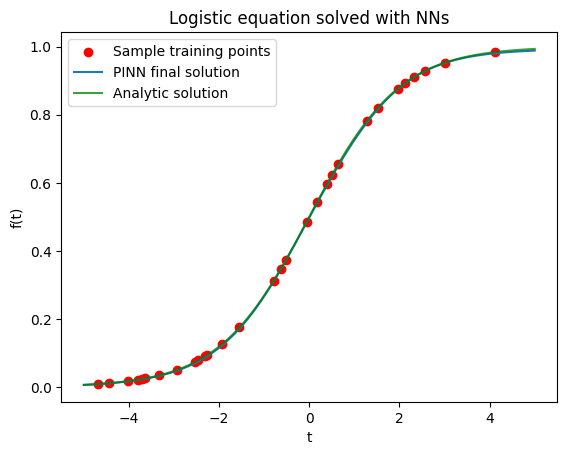

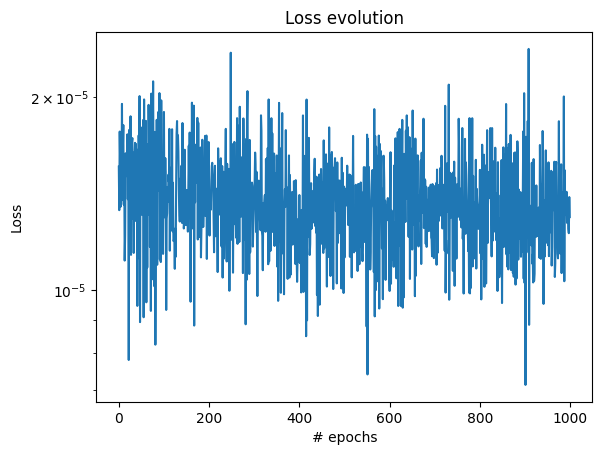

In [296]:
# creates list, with entries between 0 and 1 in 100 steps. 
# reshape brings it in form of a vector 
# -1 => the vector has as many rows as entries
# 1 => the vector has one column
x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)

# evaluates the function values to the given x values
f_eval = model_v(x_eval).squeeze()

# creates a analytical solution for comparison purposes
analytical_sol_fn = lambda x: 1.0 / (1.0 + (1.0/F_BOUNDARY - 1.0) * np.exp(-R * x))

# creates a numpy array from x_eval and detaches it from x_eval
x_eval_np = x_eval.detach().numpy()

# creates an numpy array with the x values of the sample points
x_sample_np = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1]).detach().numpy()

#creates Figures and axes for the first plot

fig, ax = plt.subplots()

# creates a scatter plot of the Sample training points
ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
# ads the PINN solution, analytical solution, title and legend to the plot
ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
ax.plot(
    x_eval_np,
    analytical_sol_fn(x_eval_np),
    label=f"Analytic solution",
    color="green",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()

#creates Figures and axes for the second plot
fig, ax = plt.subplots()
ax.semilogy(loss_evolution) #y-axis is logarithmic
ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")


plt.show()

# Similar Setup with Pytorch 2.0

In [199]:
# create the PINN model using the new pytorch API
model = NNApproximator()

params = dict(model.named_parameters())
fmodel = torch.func.functionalize(model)
x = torch.rand(3, 1)
fmodel(x)

tensor([[-0.5318],
        [-0.5460],
        [-0.5363]], grad_fn=<AddmmBackward0>)

In [157]:
from torch.func import grad
x = torch.randn([])
cos_x = grad(lambda x: torch.sin(x))(x)
print(cos_x)
assert torch.allclose(cos_x, x.cos())
# Second-order gradients
neg_sin_x = grad(grad(lambda x: torch.sin(x)))(x)
assert torch.allclose(neg_sin_x, -x.sin())

tensor(0.5637)
